In [1]:
import numpy as np
import matplotlib.pylab as pl
import torch
import ot
import ot.plot

## Data generation

In [2]:
torch.manual_seed(1)

n_source_samples = 100
n_target_samples = 100
theta = 2 * np.pi / 20
noise_level = 0.1

Xs, ys = ot.datasets.make_data_classif("gaussrot", n_source_samples, nz=noise_level)
Xt, yt = ot.datasets.make_data_classif("gaussrot", n_target_samples, nz=noise_level)

# one of the target mode changes its variance (no linear mapping)
Xt[yt == 2] *= 3
Xt = Xt + 4

Text(0.5, 1.0, 'Source and target distributions')

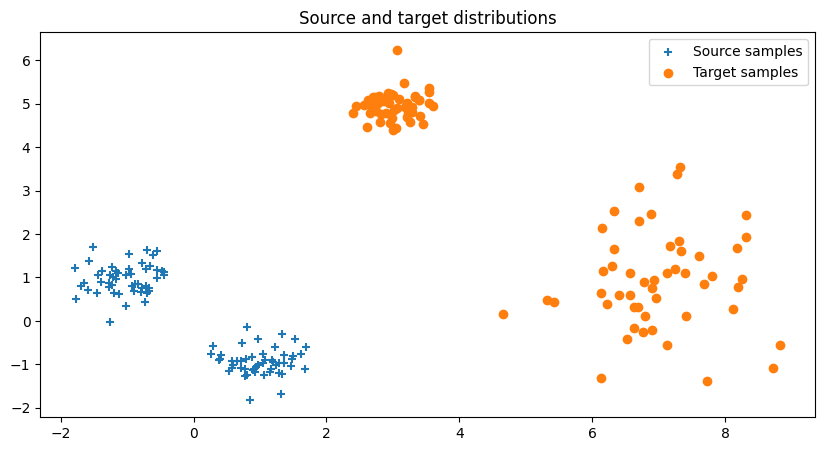

In [5]:
# Plot data
pl.figure(1, (10, 5))
pl.clf()
pl.scatter(Xs[:, 0], Xs[:, 1], marker="+", label="Source samples")
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples")
pl.legend(loc=0)
pl.title("Source and target distributions")

In [8]:
# Convert data to torch tensor
xs = torch.tensor(Xs)
xt = torch.tensor(Xt)

## Estimating dual variables for entropic OT

Iter:   0, loss=-0.0018441750987564338
Iter:  10, loss=-19.617203690092804
Iter:  20, loss=-31.882455903843898
Iter:  30, loss=-34.09404358916165
Iter:  40, loss=-36.131770952609706
Iter:  50, loss=-36.46338816655324
Iter:  60, loss=-36.64659427342312
Iter:  70, loss=-36.71405790396743
Iter:  80, loss=-36.75158845383438
Iter:  90, loss=-36.76489636876796
Iter: 100, loss=-36.770803775724886
Iter: 110, loss=-36.77404720503713
Iter: 120, loss=-36.775797003433844
Iter: 130, loss=-36.77688807925867
Iter: 140, loss=-36.7776233711732
Iter: 150, loss=-36.77815760595372
Iter: 160, loss=-36.77855601282699
Iter: 170, loss=-36.77885935749031
Iter: 180, loss=-36.77909834475678
Iter: 190, loss=-36.77929028696164


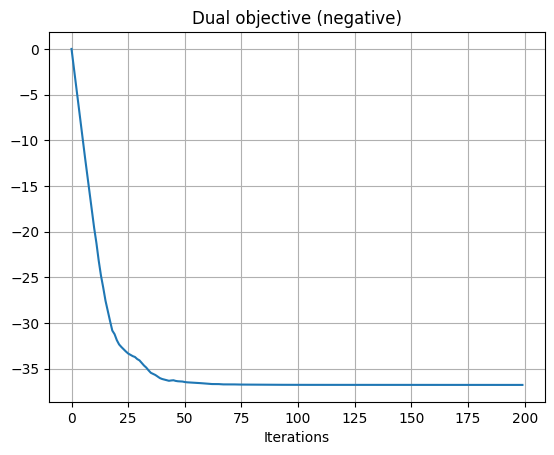

In [9]:
u = torch.randn(n_source_samples, requires_grad=True)
v = torch.randn(n_target_samples, requires_grad=True)

reg = 0.5

optimizer = torch.optim.Adam([u, v], lr=1)

# number of iteration
n_iter = 200
losses = []
for i in range(n_iter):
    # generate noise sample
    # minus because we maximize the dual loss
    loss = -ot.stochastic.loss_dual_entropic(u, v, xs, xt, reg=reg)
    losses.append(float(loss.detach()))

    if i % 10 == 0:
        print("Iter: {:3d}, loss={}".format(i, losses[-1]))

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

pl.figure(2)
pl.plot(losses)
pl.grid()
pl.title("Dual objective (negative)")
pl.xlabel("Iterations")

Ge = ot.stochastic.plan_dual_entropic(u, v, xs, xt, reg=reg)

Text(0.5, 1.0, 'Source and target distribution')

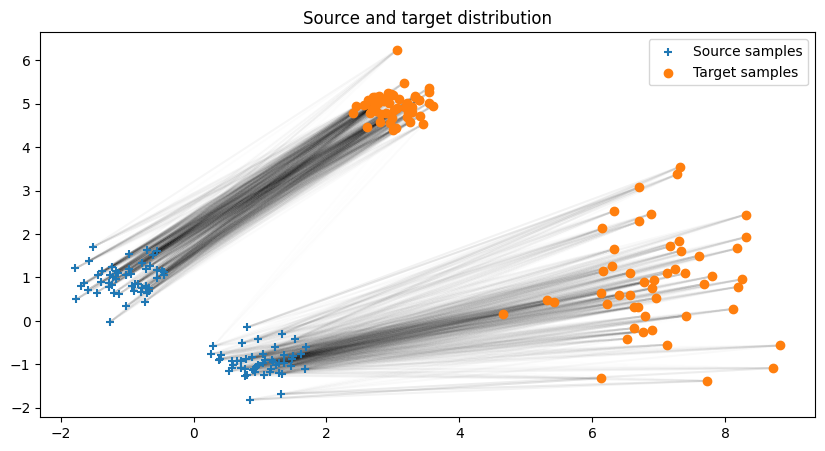

In [10]:
# Plot the estimated entropic OT plan

pl.figure(3, (10, 5))
pl.clf()
ot.plot.plot2D_samples_mat(Xs, Xt, Ge.detach().numpy(), alpha=0.1)
pl.scatter(Xs[:, 0], Xs[:, 1], marker="+", label="Source samples", zorder=2)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", zorder=2)
pl.legend(loc=0)
pl.title("Source and target distribution")

## Estimating dual variables for quandratic OT

Iter:   0, loss=0.2770306733064353
Iter:  10, loss=-19.3040635649596
Iter:  20, loss=-31.304741445402648
Iter:  30, loss=-33.67353333990766
Iter:  40, loss=-35.75510188757125
Iter:  50, loss=-36.20353791531366
Iter:  60, loss=-36.45103678870593
Iter:  70, loss=-36.54900627035404
Iter:  80, loss=-36.59930394901178
Iter:  90, loss=-36.61728134790545
Iter: 100, loss=-36.62437828052
Iter: 110, loss=-36.628117935223855
Iter: 120, loss=-36.6302721574111
Iter: 130, loss=-36.63142575360579
Iter: 140, loss=-36.63209391348203
Iter: 150, loss=-36.63251721742214
Iter: 160, loss=-36.63279582395827
Iter: 170, loss=-36.63298719680151
Iter: 180, loss=-36.63313317635305
Iter: 190, loss=-36.63325220780174


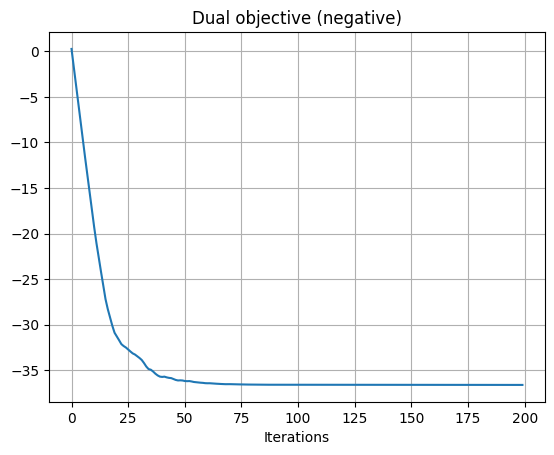

In [14]:
u = torch.randn(n_source_samples, requires_grad=True)
v = torch.randn(n_target_samples, requires_grad=True)

reg = 0.01

optimizer = torch.optim.Adam([u, v], lr=1)

# number of iteration
n_iter = 200
losses = []
for i in range(n_iter):
    # generate noise sample
    # minus because we maximize the dual loss
    loss = -ot.stochastic.loss_dual_quadratic(u, v, xs, xt, reg=reg)
    losses.append(float(loss.detach()))

    if i % 10 == 0:
        print("Iter: {:3d}, loss={}".format(i, losses[-1]))

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

pl.figure(4)
pl.plot(losses)
pl.grid()
pl.title("Dual objective (negative)")
pl.xlabel("Iterations")

Gq = ot.stochastic.plan_dual_quadratic(u, v, xs, xt, reg=reg)

Text(0.5, 1.0, 'OT plan with quandratic regularization')

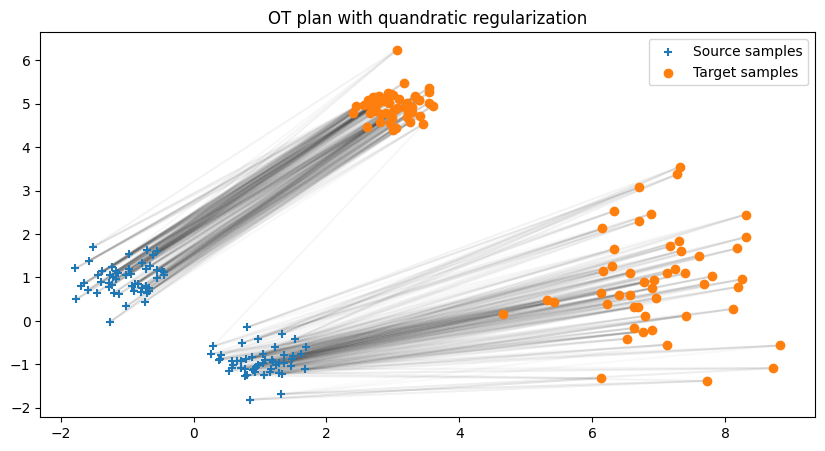

In [15]:
# Plot the estimated quandratic OT plan

pl.figure(5, (10, 5))
pl.clf()
ot.plot.plot2D_samples_mat(Xs, Xt, Gq.detach().numpy(), alpha=0.1)
pl.scatter(Xs[:, 0], Xs[:, 1], marker="+", label="Source samples", zorder=2)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", zorder=2)
pl.legend(loc=0)
pl.title("OT plan with quandratic regularization")